# Os quatros estados de Bell

Os 4 estados de Bell são a base completa do espaço de 2 qubits. Cada um representa uma correlação diferente entre os qubits, cada um representa uma correlação diferente entre os qubits

| Estado | Nome (Bell State) | Superposição | Correlação                               | Gate extra                       |
|--------|-------------------|--------------|------------------------------------------|----------------------------------|
| \|Φ⁺⟩ | Phi Plus | (\|00⟩ + \|11⟩) / √2 | 00 ou 11 sempre iguais correlação +      | —                                |
| \|Φ⁻⟩ | Phi Minus | (\|00⟩ − \|11⟩) / √2 | 00 ou 11 sempre iguais fase relativa -1  | Z no q0 depois do Φ⁺             |
| \|Ψ⁺⟩ | Psi Plus | (\|01⟩ + \|10⟩) / √2 | 01 ou 10 sempre opostos correlação anti  | X no q0 depois do Φ⁺             |
| \|Ψ⁻⟩ | Psi Minus | (\|01⟩ − \|10⟩) / √2 | 01 ou 10 sempre opostos fase relativa -1 | X e Z no q0 depois do Φ⁺ (ou iY) |

Todos os 4 estados partem do mesmo circuito base (|Φ⁺⟩), e para chegar nos outros podemos aplicar um único gate extra no qubit 0 antes do CNOT.

##### Beleza mas como ficaria isso em codigo?
No código QisKit para todos os 4, o padrão é sempre H -> CNOT, com gates opcionais antes do H para mudar o estado
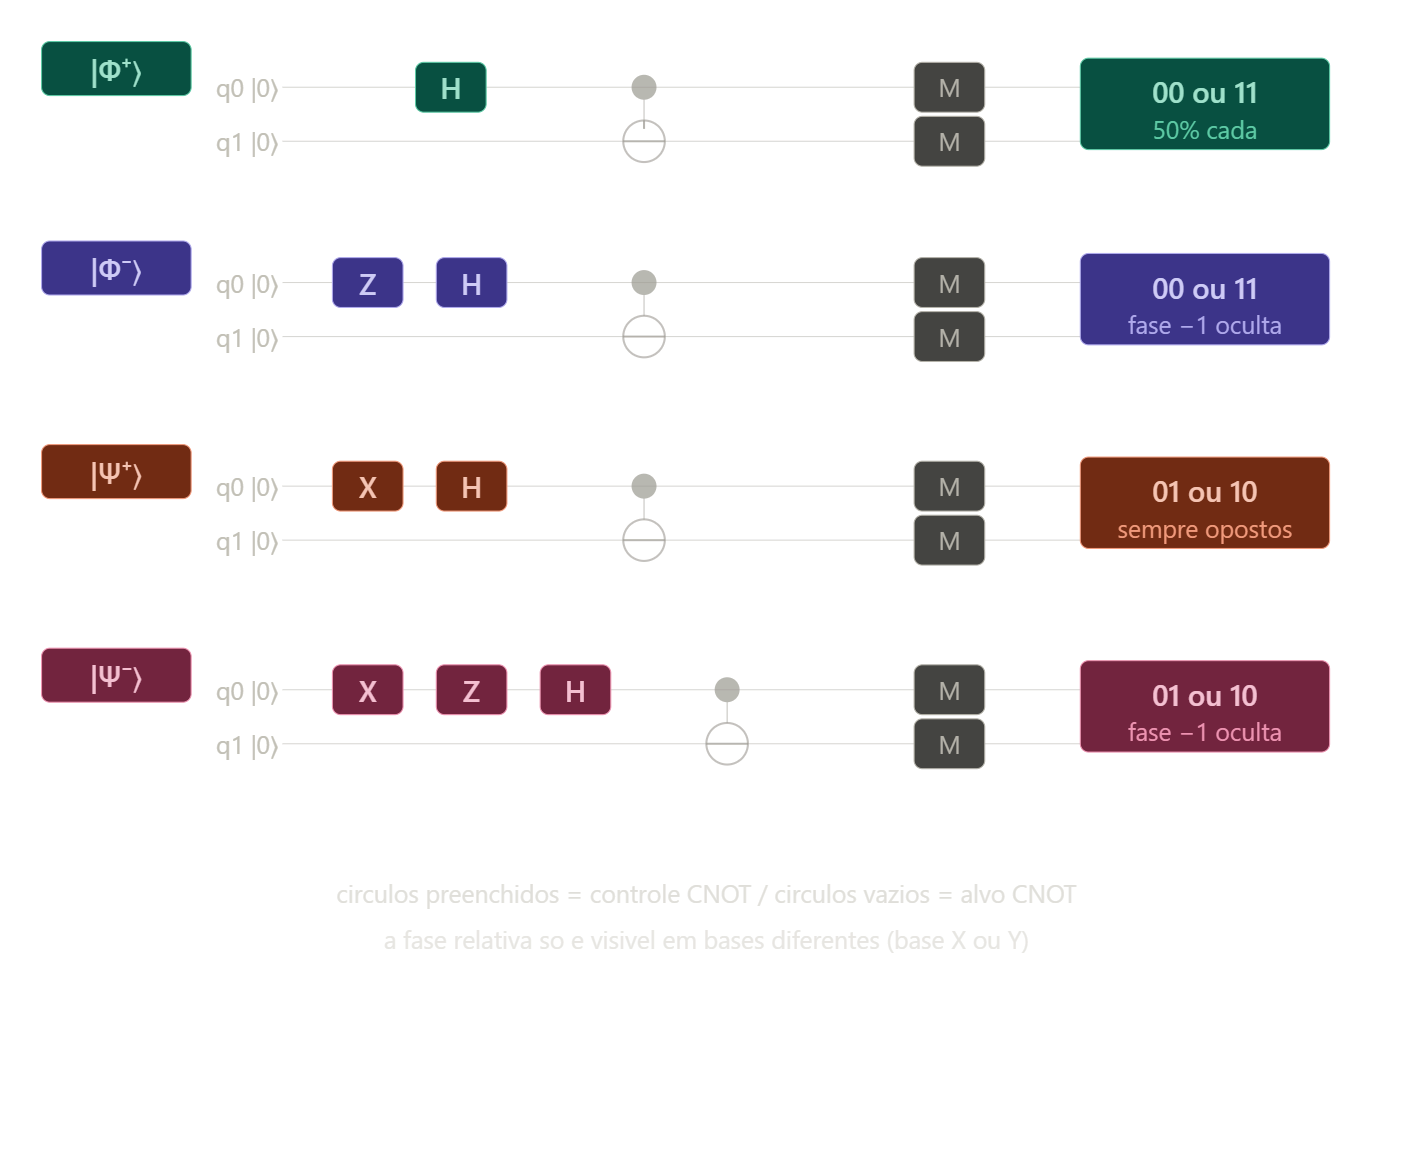

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def bell_state(name):
    qc = QuantumCircuit(2, 2)

    # Bell = Phi Plus
    if name == "phi_plus":
        # |Φ⁺⟩ = (|00⟩ + |11⟩) / √2  ← seu hello world
        qc.h(0)

    # Bell = Phi Minus
    elif name == "phi_minus":
        # |Φ⁻⟩ = (|00⟩ − |11⟩) / √2
        qc.z(0)  # fase no q0 antes do H

    # Bell = Psi Plus
    elif name == "psi_plus":
        # |Ψ⁺⟩ = (|01⟩ + |10⟩) / √2
        qc.x(0)  # flip no q0 antes do H

    # Bell = Psi Minus
    elif name == "psi_minus":
        # |Ψ⁻⟩ = (|01⟩ − |10⟩) / √2
        qc.x(0)  # flip + fase
        qc.z(0)

    # Parte comum a todos os 4:
    qc.h(0)       # H cria superposição
    qc.cx(0, 1)   # CNOT entrelaça os qubits

    qc.measure([0, 1], [0, 1])
    return qc

sim = AerSimulator()

for estado in ["phi_plus", "phi_minus", "psi_plus", "psi_minus"]:
    qc = bell_state(estado)
    job = sim.run(qc, shots=1000)
    counts = job.result().get_counts()
    print(f"{estado}: {counts}")


phi_plus: {'00': 497, '11': 503}
phi_minus: {'11': 498, '00': 502}
psi_plus: {'11': 503, '00': 497}
psi_minus: {'00': 491, '11': 509}


Ponto importante - |Φ⁺⟩ (Phi plus) e |Φ⁻⟩ (Phi minus) produzem as mesmas contagens na base computacional. A diferença de fase entre eles só aparece se medirmos na base X (adicionando um H antes de medir).